In [3]:
import pandas as pd
import numpy as np
from click.formatting import iter_rows

# Desafios de Consolidação em Pandas

Antes de avançarmos para novos conteúdos, vamos começar com alguns **desafios práticos**.

O objetivo destes exercícios é testar a vossa capacidade de:
- Ler e interpretar dados
- Selecionar, filtrar e transformar informação
- Trabalhar com índices e colunas
- Ordenar dados de diferentes formas
---

## Desafio 1 — Limpeza e Organização

Considere o seguinte DataFrame:

In [132]:
df = pd.DataFrame({
    "Nome": ["Ana", "Bruno", "Carlos", "Ana", "Bruno"],
    "Idade": [23, np.nan, 35, 23, 40],
    "Cidade": ["Lisboa", "Porto", "Lisboa", "Coimbra", "Porto"],
    "Score": [88, 92, np.nan, 88, 75]
}, index=[3, 1, 4, 0, 2])
df

,Nome,Idade,Cidade,Score
3,Ana,23.0,Lisboa,88.0
1,Bruno,NaN,Porto,92.0
4,Carlos,35.0,Lisboa,NaN
0,Ana,23.0,Coimbra,88.0
2,Bruno,40.0,Porto,75.0


Objetivos:
- Reorganize o DataFrame pelo index em ordem crescente
- Remova linhas com valores em falta na coluna "Score"
- Substitua valores em falta na coluna "Idade" pela média da coluna
- Ordene o resultado final pela coluna "Score" em ordem decrescente

In [133]:
# 1. Ordenar pelo index
df = df.sort_index()

# 2. Remover linhas com NaN em "Score"
df = df.dropna(subset=["Score"])

# 3. Substituir NaN em "Idade" pela média
df["Idade"] = df["Idade"].fillna(df["Idade"].mean())

# 4. Ordenar por "Score" (descendente)
df = df.sort_values(by="Score", ascending=False)

df

,Nome,Idade,Cidade,Score
1,Bruno,28.666667,Porto,92.0
0,Ana,23.000000,Coimbra,88.0
3,Ana,23.000000,Lisboa,88.0
2,Bruno,40.000000,Porto,75.0


## Desafio 2 — Limpeza e Organização

Considere o seguinte DataFrame:

In [134]:
df = pd.DataFrame({
    "Produto": ["A", "B", "C", "D", "E"],
    "Preco": [10, 20, 15, 30, 25],
    "Quantidade": [100, 150, 80, 200, 50],
    "Categoria": ["X", "Y", "X", "Y", "X"]
})

In [135]:
df

,Produto,Preco,Quantidade,Categoria
0,A,10,100,X
1,B,20,150,Y
2,C,15,80,X
3,D,30,200,Y
4,E,25,50,X


In [139]:
#filtro de uma coluna usando loc
df.loc[:,"Produto"]=="A"

0     True
1    False
2    False
3    False
4    False
Name: Produto, dtype: bool

Objetivos:
- Selecione apenas os produtos da categoria "X"
- Crie uma nova coluna "Valor_Total" = Preco * Quantidade
- Filtre os produtos com "Valor_Total" superior a 1000
- Ordene o resultado por "Valor_Total" (ordem decrescente)

In [21]:
# 1. Filtrar categoria X
df_filtrado = df[df["Categoria"] == "X"]

# 2. Criar coluna Valor_Total
df_filtrado["Valor_Total"] = df_filtrado["Preco"] * df_filtrado["Quantidade"]

# 3. Filtrar Valor_Total > 1000
df_filtrado = df_filtrado[df_filtrado["Valor_Total"] > 1000]

# 4. Ordenar por Valor_Total (crescente)
df_filtrado = df_filtrado.sort_values(by="Valor_Total",ascending=False)

df_filtrado

,Produto,Preco,Quantidade,Categoria,Valor_Total
4,E,25,50,X,1250
2,C,15,80,X,1200


## Desafio 3 — Alinhamento e Ordenação
Considere as seguintes Series:

In [161]:
s1 = pd.Series([10, 20, 30], index=["a", "b", "c"])
s2 = pd.Series([5, 15, 25], index=["b", "c", "d"])

In [162]:
#mudar nome de s1
s1.name = "Série 1"
s1

a    10
b    20
c    30
Name: Série 1, dtype: int64

In [163]:
s2.name = "Série 2"
s2

b     5
c    15
d    25
Name: Série 2, dtype: int64

In [164]:
#sum s1 e s2 but keeping the value with NaN if there is no match
soma = s1 + s2

#and sum again but filling NaN with 0
soma_filled = s1.add(s2, fill_value=0)
soma_filled

a    10.0
b    25.0
c    45.0
d    25.0
dtype: float64

In [165]:
s1

a    10
b    20
c    30
Name: Série 1, dtype: int64

In [166]:
s2

b     5
c    15
d    25
Name: Série 2, dtype: int64

In [155]:
#concat s1 e s2 em um DataFrame
df = pd.concat([s1, s2], axis=1)
df

,Série 1,Série 2
a,10.0,NaN
b,20.0,5.0
c,30.0,15.0
d,NaN,25.0


Objetivos:
- Some as duas Series
- Mude a descricao da serie para "Resultado"
- Remova os valores NaN
- Ordene os valores pela coluna "Resultado" em ordem crescente
- Reindexe o DataFrame para ter índices "b", "c" (nessa ordem)

In [22]:
# 1. Soma (com alinhamento automático)
resultado = s1 + s2

# 2. Converter para DataFrame
df = resultado.to_frame(name="Resultado")

# 3. Remover NaN
df = df.dropna()

# 4. Ordenar valores
df = df.sort_values(by="Resultado")

# 5. Reindexar
df = df.reindex(["b", "c"])

df

,Resultado
b,25.0
c,45.0


# Continuação revisão Pandas — Consolidação

In [23]:
obj = pd.Series(np.arange(5), index=["a", "a", "b", "b", "c"])
obj

a    0
a    1
b    2
b    3
c    4
dtype: int64

In [24]:
obj.index.is_unique

False

In [25]:
obj["a"]

a    0
a    1
dtype: int64

In [26]:
#agora vamos somar dados
df = pd.DataFrame([[1.4, np.nan],
                   [7.1,-4.5],
                   [np.nan, np.nan],
                   [0.75,-1.3]],
                  index=["a", "b", "c", "d"],
                  columns=["one", "two"])

df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [28]:
df.sum() # soma as duas colunas

one    9.25
two   -5.80
dtype: float64

In [29]:
df.sum(axis=1) # soma as linhas

a    1.40
b    2.60
c    0.00
d   -0.55
dtype: float64

In [31]:
df.sum(axis="columns", skipna=False)
#com skipna=False, o resultado é NaN se houver algum valor NaN na linha

a     NaN
b    2.60
c     NaN
d   -0.55
dtype: float64

In [32]:
#para calcular media de uma coluna
df.mean()

one    3.083333
two   -2.900000
dtype: float64

In [33]:
df.idxmax() #

one    b
two    d
dtype: str

In [37]:
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [44]:
for i,idx in df.idxmax().items():
    print(f" A coluna {i} tem o seu maior valor no index {idx}")

 A coluna one tem o seu maior valor no index b
 A coluna two tem o seu maior valor no index d


In [45]:
df.describe() # describe de um DataFrame

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [46]:
obj = pd.Series(["a", "a", "b", "c"] * 4)
obj

0     a
1     a
2     b
3     c
4     a
5     a
6     b
7     c
8     a
9     a
10    b
11    c
12    a
13    a
14    b
15    c
dtype: str

In [47]:
obj.describe() # describe de uma Series

count     16
unique     3
top        a
freq       8
dtype: object

In [49]:
obj = pd.Series([1,3,5,8,3,6,9,10,0,7,7,5])
obj.describe() #muda se for uma serie de numeros ou de strings

count    12.000000
mean      5.333333
std       3.113996
min       0.000000
25%       3.000000
50%       5.500000
75%       7.250000
max      10.000000
dtype: float64

![Descriptive and summary statistics](table3.png)

In [90]:
#read csv from ./data folder
auto = pd.read_csv("./data/auto2.csv", index_col=0)

In [63]:
auto.head()

,engine-type,num-of-cylinders,horsepower,average-mileage,price
index,,,,,
0,dohc,four,111,21,13495.0
1,dohc,four,111,21,16500.0
2,ohcv,six,154,19,16500.0
3,ohc,four,102,24,13950.0
4,ohc,five,115,18,17450.0


In [64]:
#read txt from ./data folder
netflix = pd.read_csv("./data/netflix.txt",index_col=0)

In [65]:
netflix.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [66]:
#read excel from ./data folder
commerce = pd.read_excel("./data/e-commerce.xlsx")

In [67]:
commerce.head()

,Email,Address,Avatar,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [68]:
#read json from ./data folder
json_df = pd.read_json("./data/data.json")

In [69]:
json_df

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0
...,...,...,...,...
164,60,105,140,290.8
165,60,110,145,300.4
166,60,115,145,310.2
167,75,120,150,320.4


In [73]:
#explicando groupby
df = pd.DataFrame({
    "key": ["A", "B", "C", "A", "B", "C"],
    "data": [1, 2, 3, 4, 5, 6],
    "data2": [7, 8, 9, 10, 11, 12]
})

grouped = df.groupby("key")
df

,key,data,data2
0,A,1,7
1,B,2,8
2,C,3,9
3,A,4,10
4,B,5,11
5,C,6,12


In [74]:
grouped.sum()
#o groupby agrupa os dados por chave e depois aplica a função de agregação (neste caso, soma) a cada grupo. O resultado é um DataFrame onde as chaves são os índices e as colunas são as somas dos dados para cada grupo.

,data,data2
key,,
A,5,17
B,7,19
C,9,21


## Exercício de Consolidação
Usando o dataframe `auto` que carregamos anteriormente, responda às seguintes perguntas:
1. Qual é a média do preço dos carros por tipo de motor?
2. Qual é a marca com o maior número de carros listados?
3. Qual é a média milhas por marca?
4. Separe horsepower em 3 classes, baixo, médio e alto e calculo a media do preço e mileage.
5. Qual é o top 5 carros mais caros?
6. Qual é o top 5 carros mais baratos?
7. Agrupe por engine-type e por num-of-cylinders e calcule a média do preço.

In [76]:
auto

,engine-type,num-of-cylinders,horsepower,average-mileage,price
index,,,,,
0,dohc,four,111,21,13495.0
1,dohc,four,111,21,16500.0
2,ohcv,six,154,19,16500.0
3,ohc,four,102,24,13950.0
4,ohc,five,115,18,17450.0
...,...,...,...,...,...
81,ohc,four,85,27,7975.0
82,ohc,four,52,37,7995.0
86,ohc,four,100,26,9995.0


In [77]:
# 1. Média do preço por marca
media_preco_tipo = auto.groupby("engine-type")["price"].mean()
print("Média do preço dos carros por tipo de motor:")
print(media_preco_tipo)

Média do preço dos carros por tipo de motor:
engine-type
dohc     22709.000000
dohcv             NaN
l         5151.000000
ohc      12238.409091
ohcf     35528.000000
ohcv     30471.800000
rotor    11845.000000
Name: price, dtype: float64


In [78]:
#dropna coluna "price" para calcular a média do consumo de combustível por tipo de carro
auto_clean = auto.dropna(subset=["price"])
media_preco_tipo = auto_clean.groupby("engine-type")["price"].mean()
print("Média do preço dos carros por tipo de motor:")
print(media_preco_tipo)

Média do preço dos carros por tipo de motor:
engine-type
dohc     22709.000000
l         5151.000000
ohc      12238.409091
ohcf     35528.000000
ohcv     30471.800000
rotor    11845.000000
Name: price, dtype: float64


In [80]:
auto[auto["engine-type"]=="dohcv"].describe()

,horsepower,average-mileage,price
count,1.0,1.0,0.0
mean,288.0,17.0,NaN
std,NaN,NaN,NaN
min,288.0,17.0,NaN
25%,288.0,17.0,NaN
50%,288.0,17.0,NaN
75%,288.0,17.0,NaN
max,288.0,17.0,NaN


In [81]:
#Qual é a marca com o maior número de carros listados?
auto["engine-type"].value_counts()

engine-type
ohc      46
dohc      5
ohcv      5
ohcf      2
l         1
rotor     1
dohcv     1
Name: count, dtype: int64

In [83]:
# Qual é a média milhas por marca?
media_milha_marca = auto.groupby("engine-type")["average-mileage"].mean()
print(media_milha_marca)

engine-type
dohc     18.200000
dohcv    17.000000
l        47.000000
ohc      28.021739
ohcf     17.000000
ohcv     15.800000
rotor    17.000000
Name: average-mileage, dtype: float64


In [91]:
# Separe horsepower em 3 classes, baixo, médio e alto e calculo a media do preço e mileage.
# analise da distribuicao para definir os intervalos
auto["horsepower"].describe()

count     61.000000
mean     107.852459
std       53.524398
min       48.000000
25%       68.000000
50%      100.000000
75%      123.000000
max      288.000000
Name: horsepower, dtype: float64

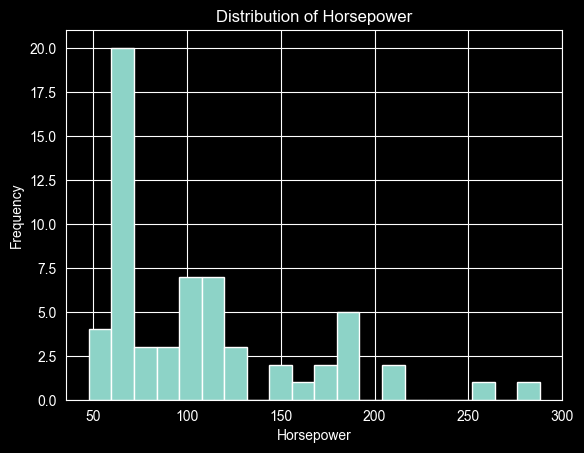

In [94]:
#create a histogram of horsepower
import matplotlib.pyplot as plt
plt.hist(auto["horsepower"].dropna(), bins=20)
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.title("Distribution of Horsepower")
plt.show()

In [95]:
auto["horsepower_class"] = pd.cut(auto["horsepower"], bins=[0, 50, 150, np.inf], labels=["baixo", "médio", "alto"])

In [96]:
auto

,engine-type,num-of-cylinders,horsepower,average-mileage,price,horsepower_class
index,,,,,,
0,dohc,four,111,21,13495.0,médio
1,dohc,four,111,21,16500.0,médio
2,ohcv,six,154,19,16500.0,alto
3,ohc,four,102,24,13950.0,médio
4,ohc,five,115,18,17450.0,médio
...,...,...,...,...,...,...
81,ohc,four,85,27,7975.0,médio
82,ohc,four,52,37,7995.0,médio
86,ohc,four,100,26,9995.0,médio


In [97]:
media_preco_milha = auto.groupby("horsepower_class")[["price", "average-mileage"]].mean()
media_preco_milha

,price,average-mileage
horsepower_class,,
baixo,5151.000000,47.000000
médio,10713.068182,28.282609
alto,31993.846154,16.142857


In [98]:
auto[auto["horsepower_class"] == "alto"]

,engine-type,num-of-cylinders,horsepower,average-mileage,price,horsepower_class
index,,,,,,
2,ohcv,six,154,19,16500.0,alto
13,ohc,six,182,16,30760.0,alto
14,ohc,six,182,16,41315.0,alto
15,ohc,six,182,15,36880.0,alto
33,dohc,six,176,15,32250.0,alto
34,dohc,six,176,15,35550.0,alto
35,ohcv,twelve,262,13,36000.0,alto
46,ohcv,eight,184,14,40960.0,alto
47,ohcv,eight,184,14,45400.0,alto


In [100]:
# Qual é o top 5 carros mais caros?
top5_carros_caros = auto.nlargest(5, "price")
print("Top 5 carros mais caros:")
top5_carros_caros

Top 5 carros mais caros:


,engine-type,num-of-cylinders,horsepower,average-mileage,price,horsepower_class
index,,,,,,
47,ohcv,eight,184,14,45400.0,alto
14,ohc,six,182,16,41315.0,alto
46,ohcv,eight,184,14,40960.0,alto
62,ohcf,six,207,17,37028.0,alto
15,ohc,six,182,15,36880.0,alto


In [101]:
# Qual é o top 5 carros mais baratos?
top5_carros_baratos = auto.nsmallest(5, "price")
print("Top 5 carros mais baratos:")
top5_carros_baratos

Top 5 carros mais baratos:


,engine-type,num-of-cylinders,horsepower,average-mileage,price,horsepower_class
index,,,,,,
16,l,three,48,47,5151.0,baixo
36,ohc,four,68,30,5195.0,médio
66,ohc,four,62,35,5348.0,médio
49,ohc,four,68,37,5389.0,médio
37,ohc,four,68,31,6095.0,médio


In [104]:
# Agrupe por engine-type e por num-of-cylinders e calcule a média do preço.
media_preco_grupo = auto.groupby(["engine-type", "num-of-cylinders"])[["price","horsepower"]].mean()
print("Média do preço por tipo de motor e número de cilindros:")
media_preco_grupo

Média do preço por tipo de motor e número de cilindros:


price  horsepower
engine-type num-of-cylinders                          
dohc        four              14997.500000  111.000000
            six               27850.000000  169.333333
dohcv       eight                      NaN  288.000000
l           three              5151.000000   48.000000
ohc         five              21084.000000  116.200000
            four               8661.285714   76.054054
            six               32481.250000  166.750000
ohcf        six               35528.000000  207.000000
ohcv        eight             43180.000000  184.000000
            six               14999.500000  153.000000
            twelve            36000.000000  262.000000
rotor       two               11845.000000  101.000000

# Desafio de Consolidação 2
Utilizando o dataframe `netflix` que carregamos anteriormente, responda às seguintes perguntas:
1. Segmente o dataset netflix em dois. netflix_movies e netflix_tvshows?
2. Quantos filmes e quantas séries estão disponíveis na plataforma?
3. Qual é o género que possui mais filmes na plataforma?
4. Localize e liste as series que possuem a palavra "love" em sua descrição.
5. Qual é a média de duração dos filmes por género para filmes?
6. Qual é a média de Seasons por género para séries?
7. Qual é o top 5 filmes mais longos?
8. Qual é o top 5 séries com mais seasons?

In [106]:
netflix

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In [107]:
#Segmente o dataset netflix em dois. netflix_movies e netflix_tvshows?#
netflix_movies = netflix[netflix["type"] == "Movie"]
netflix_tvshows = netflix[netflix["type"] == "TV Show"]

In [108]:
# Quantos filmes e quantas séries estão disponíveis na plataforma?
num_filmes = netflix_movies.shape[0]
num_series = netflix_tvshows.shape[0]
print(f"Número de filmes: {num_filmes}")
print(f"Número de séries: {num_series}")

Número de filmes: 6131
Número de séries: 2676


In [113]:
# Qual é o género que possui mais filmes na plataforma?
# transformar a coluna "listed_in" em uma lista de gêneros
netflix_movies["genres"] = netflix_movies["listed_in"].str.split(", ")
#drop listed_in
del netflix_movies["listed_in"]
# Explodir a coluna "genres" para contar cada gênero individualmente
netflix_movies_exploded = netflix_movies.explode("genres")
# Contar o número de filmes por gênero
genero_mais_filmes = netflix_movies_exploded["genres"].value_counts()
genero_mais_filmes


genres
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Anime Features                71
Cult Movies                   71
Faith & Spirituality          65
Movies                        57
Name: count, dtype: int64

In [115]:
netflix_movies

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres
show_id,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Documentaries]
s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,[Children & Family Movies]
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...","[Dramas, Independent Movies, International Mov..."
s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,"[Comedies, Dramas]"
s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,"[Dramas, International Movies]"
...,...,...,...,...,...,...,...,...,...,...,...,...
s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,"[Dramas, International Movies, Thrillers]"
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...","[Cult Movies, Dramas, Thrillers]"
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,"[Comedies, Horror Movies]"


In [119]:
# Localize e liste as series que possuem a palavra "love" em sua descrição.
def contains_love(description):
    if pd.isna(description):
        return False
    return "love" in description.lower()

# text = "Love is in the air"
# print(contains_love(text))  # True

netflix_tvshows["contains_love"] = netflix_tvshows["description"].apply(contains_love)
series_com_love = netflix_tvshows[netflix_tvshows["contains_love"]]
print("Séries que possuem a palavra 'love' em sua descrição:")
series_com_love[["title", "description"]]

Séries que possuem a palavra 'love' em sua descrição:


,title,description
show_id,,
s26,Love on the Spectrum,Finding love can be hard for anyone. For young...
s48,The Smart Money Woman,Five glamorous millennials strive for success ...
s100,On the Verge,"Four women — a chef, a single mom, an heiress ..."
s246,Korean Cold Noodle Rhapsody,"Refreshing and flavorful, naengmyeon is Korea'..."
s274,Gone for Good,"Ten years after losing two loved ones, a man i..."
...,...,...
s8524,The Super Mario Bros. Super Show!,"Mixing live action and animation, this classic..."
s8561,The Womanizer,Libertine He-jie finds himself torn between th...
s8576,This Is My Love,A renowned actor who is still pining over the ...


In [120]:
netflix_movies_exploded

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres
show_id,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Children & Family Movies
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Dramas
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Independent Movies
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...
s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Children & Family Movies
s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Comedies
s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Dramas


In [121]:
#convert duration in netflix_movies_exploded to numeric, removing the " min" suffix
netflix_movies_exploded["duration"] = netflix_movies_exploded["duration"].str.replace(" min", "").astype(float)

In [122]:
netflix_movies_exploded

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres
show_id,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91.0,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,Children & Family Movies
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Dramas
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Independent Movies
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...
s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88.0,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Children & Family Movies
s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88.0,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Comedies
s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111.0,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Dramas


In [125]:
#Qual é a média de duração dos filmes por género para filmes?
media_movies_genero = netflix_movies_exploded.groupby(["genres"])[["duration"]].mean()
media_movies_genero.sort_values(by="duration", ascending=False, inplace=True)
media_movies_genero


,duration
genres,
Classic Movies,118.646552
Action & Adventure,113.515716
Dramas,113.051092
Romantic Movies,110.573052
International Movies,110.349927
Thrillers,107.166378
Music & Musicals,106.125333
Sci-Fi & Fantasy,106.016461
Faith & Spirituality,105.584615


In [126]:
netflix_tvshows

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,contains_love
show_id,,,,,,,,,,,,
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",False
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,False
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",False
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,False
s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,False
...,...,...,...,...,...,...,...,...,...,...,...,...
s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...,False
s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves...",False
s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...,False


In [127]:
# Qual é a média de Seasons por género para séries?
# transformar a coluna "listed_in" em uma lista de gêneros
netflix_tvshows["genres"] = netflix_tvshows["listed_in"].str.split(", ")
del netflix_tvshows["listed_in"]
# extrair o número de seasons da coluna "duration"
netflix_tvshows["seasons"] = netflix_tvshows["duration"].str.extract(r'(\d+) Seasons?').astype(float)
# Explodir a coluna "genres" para contar cada gênero individualmente
netflix_tvshows_exploded = netflix_tvshows.explode("genres")
# Calcular a média de seasons por gênero
media_seasons_genero = netflix_tvshows_exploded.groupby("genres")["seasons"].mean()
media_seasons_genero.sort_values(ascending=False, inplace=True)
media_seasons_genero

genres
Classic & Cult TV               5.678571
TV Sci-Fi & Fantasy             2.654762
TV Action & Adventure           2.398810
Teen TV Shows                   2.246377
TV Mysteries                    2.193878
TV Comedies                     2.151463
TV Horror                       2.106667
TV Thrillers                    2.052632
Kids' TV                        1.977827
TV Dramas                       1.850590
Stand-Up Comedy & Talk Shows    1.839286
British TV Shows                1.818182
Crime TV Shows                  1.708511
Anime Series                    1.573864
Reality TV                      1.552941
Spanish-Language TV Shows       1.540230
International TV Shows          1.410067
Romantic TV Shows               1.397297
Docuseries                      1.336709
Science & Nature TV             1.293478
Korean TV Shows                 1.264901
TV Shows                        1.000000
Name: seasons, dtype: float64

In [130]:
# Qual é o top 5 filmes mais longos?
#convert duration in netflix_movies to numeric, removing the " min" suffix
netflix_movies["duration"] = netflix_movies["duration"].str.replace(" min", "").astype(float)
top5_filmes_longos = netflix_movies.nlargest(5, "duration")
print("Top 5 filmes mais longos:")
top5_filmes_longos[["title", "duration"]]

Top 5 filmes mais longos:


,title,duration
show_id,,
s4254,Black Mirror: Bandersnatch,312.0
s718,Headspace: Unwind Your Mind,273.0
s2492,The School of Mischief,253.0
s2488,No Longer kids,237.0
s2485,Lock Your Girls In,233.0


In [131]:
#Qual é o top 5 séries com mais seasons?
#extrair o número de seasons da coluna "duration" em netflix_tvshows
netflix_tvshows["seasons"] = netflix_tvshows["duration"].str.extract(r'(\d+) Seasons?').astype(float)
top5_series_seasons = netflix_tvshows.nlargest(5, "seasons")
print("Top 5 séries com mais seasons:")
top5_series_seasons[["title", "seasons"]]

Top 5 séries com mais seasons:


,title,seasons
show_id,,
s549,Grey's Anatomy,17.0
s2424,Supernatural,15.0
s4799,NCIS,15.0
s1355,Heartland,13.0
s4221,COMEDIANS of the world,13.0
